# SSH Open Marketplace – Catalogue Analysis
**DARIAH ERIC | Research Software Engineer Task – Option C**

---

## My Approach

The SSH Open Marketplace is a catalogue of research tools, training materials, publications, datasets and workflows for Social Sciences and Humanities researchers. It exposes a public REST API at `https://marketplace-api.sshopencloud.eu/api`.

I chose **Option C (Catalogue Analysis)** because it lets me explore the full breadth of the catalogue and answer meaningful questions about its content and quality.

**Note:** The Swagger UI link in the task brief returned a 404. I explored the API directly by reading its live JSON responses, which gave me everything I needed to understand the data structure.

**Questions I want to answer:**
1. How many items are in the catalogue, and how are they split by type?
2. How well are key metadata fields filled in?
3. Which controlled vocabularies are used to tag items, and which concepts are most common?
4. Which data sources contribute the most items?
5. How recently have items been updated — is the catalogue actively maintained?

## Step 0 – Imports and Setup

In [9]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make all charts look clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Imports done.")

Imports done.


## Step 1 – Understand the API

Before writing any analysis, I read the API responses directly to understand the structure.

Key things I learned:
- Base URL: `https://marketplace-api.sshopencloud.eu/api`
- No login needed for reading data (GET requests are public)
- Pagination works with `?page=1&perpage=50` query parameters
- The response always has a `hits` field = total number of items
- Each item type has its own endpoint and its own array key in the response
- Each item has fields like: `label`, `description`, `source`, `lastInfoUpdate`, `accessibleAt`, `contributors`, `properties`

In [10]:
# The base URL for all API calls
BASE_URL = "https://marketplace-api.sshopencloud.eu/api"

# Each item type, its API endpoint, and the key that holds the list of items in the response.
# I discovered these by reading real API responses.
ITEM_TYPES = {
    "tools-services":     {"label": "Tool or Service",   "array_key": "tools"},
    "training-materials": {"label": "Training Material", "array_key": "trainingMaterials"},
    "publications":       {"label": "Publication",       "array_key": "publications"},
    "datasets":           {"label": "Dataset",           "array_key": "datasets"},
    "workflows":          {"label": "Workflow",          "array_key": "workflows"},
}

def get_data(endpoint, params=None):
    """
    Call the API and return the JSON response.
    timeout=40 means: if the server takes more than 40 seconds, give up.
    """
    url = f"{BASE_URL}/{endpoint}"
    response = requests.get(url, params=params, timeout=40)
    response.raise_for_status()  # this raises an error if status is not 200 OK
    return response.json()

# Quick test: fetch 1 item from each type to get the total count
print("Total items per type in the full catalogue:\n")
type_totals = {}  # store totals here

for endpoint, info in ITEM_TYPES.items():
    if endpoint == "workflows":
        continue
    data = get_data(endpoint, params={"page": 1, "perpage": 1})
    total = data["hits"]
    type_totals[info["label"]] = total
    print(f"  {info['label']:<25} {total:>5} items")
    time.sleep(0.5)

print(f"\n  {'TOTAL':<25} {sum(type_totals.values()):>5} items")

Total items per type in the full catalogue:

  Tool or Service            2691 items
  Training Material           970 items
  Publication                 585 items
  Dataset                    1771 items

  TOTAL                      6017 items


In [11]:
# Look at one real item to understand the field structure before writing analysis
sample = get_data("tools-services", params={"page": 1, "perpage": 1})
item = sample["tools"][0]  # get the first item

print("Example item fields:")
print(f"  label         : {item['label']}")
print(f"  lastInfoUpdate: {item.get('lastInfoUpdate')}")
print(f"  source        : {item.get('source', {}).get('label')}")
print(f"  accessibleAt  : {item.get('accessibleAt')}")  # list of URLs
print(f"  contributors  : {len(item.get('contributors', []))} people/orgs")
print(f"  properties    : {len(item.get('properties', []))} tags")
print(f"  externalIds   : {len(item.get('externalIds', []))} identifiers")

Example item fields:
  label         : 140kit
  lastInfoUpdate: 2025-01-30T09:59:57+0000
  source        : TAPoR
  accessibleAt  : ['https://github.com/WebEcologyProject/140kit']
  contributors  : 2 people/orgs
  properties    : 10 tags
  externalIds   : 0 identifiers


## Step 2 – Fetch a Sample

I fetch up to 200 items per type. This gives me 1,000 items total — enough to find patterns without taking too long.

In [12]:
def fetch_items(endpoint, array_key, max_items=200, perpage=50):
    """
    Fetch up to max_items records from the API by going through pages one by one.
    
    - endpoint:  which API path to call (e.g. 'tools-services')
    - array_key: the key in the response that holds the list (e.g. 'tools')
    - max_items: stop after collecting this many items
    - perpage:   how many items to request per page
    """
    collected = []  # list to store all items
    page = 1

    while len(collected) < max_items:
        # Request one page of results
        data = get_data(endpoint, params={"page": page, "perpage": perpage})
        
        # Get the list of items from this page
        batch = data.get(array_key, [])
        
        if not batch:  # empty page = we've reached the end
            break
            
        collected.extend(batch)
        
        # Stop if we've gone through all pages
        if page >= data.get("pages", 1):
            break
            
        page += 1
        time.sleep(0.5)  # pause between pages

    return collected[:max_items]  # trim to exactly max_items


# Fetch samples for all item types
all_samples = {}

for endpoint, info in ITEM_TYPES.items():
    if endpoint == "workflows":
        print(f"Skipping Workflow (API endpoint consistently timed out)")
        all_samples[info["label"]] = []
        continue
    print(f"Fetching {info['label']}...", end=" ", flush=True)
    items = fetch_items(endpoint, info["array_key"], max_items=200)
    all_samples[info["label"]] = items
    print(f"{len(items)} items fetched")

print("\nAll done!")

Fetching Tool or Service... 200 items fetched
Fetching Training Material... 200 items fetched
Fetching Publication... 200 items fetched
Fetching Dataset... 200 items fetched
Skipping Workflow (API endpoint consistently timed out)

All done!


## Question 1 – How are items distributed across types?

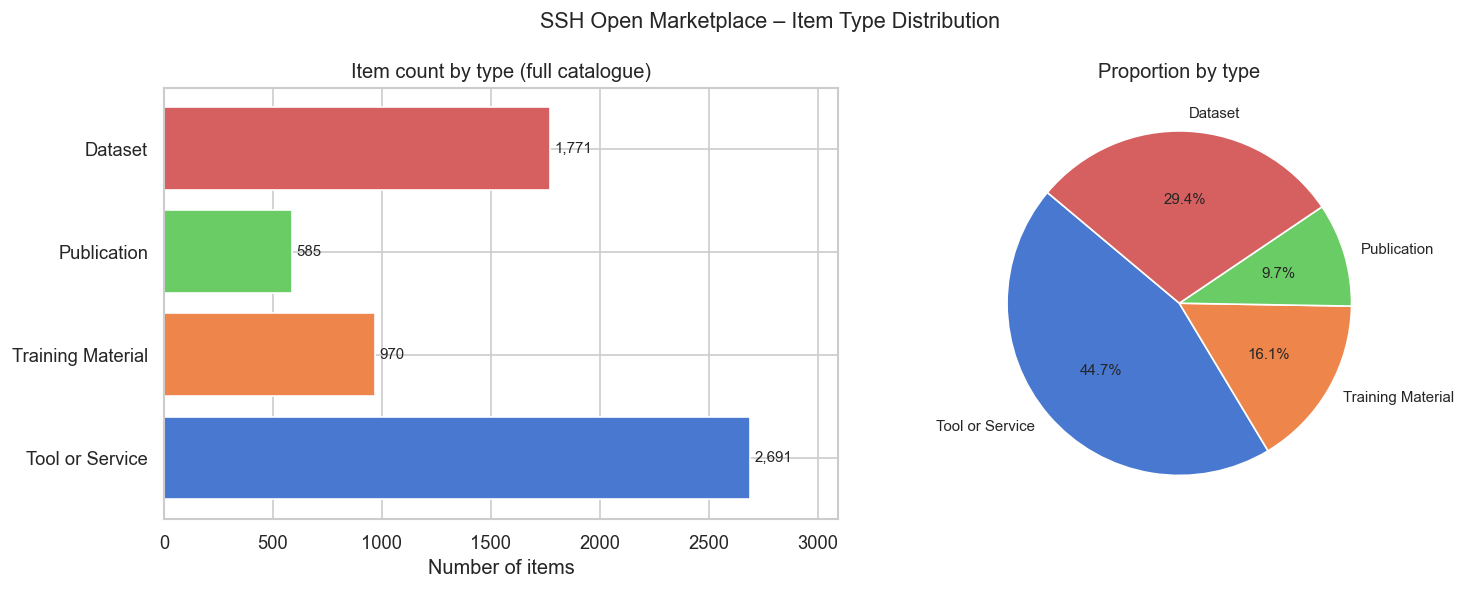

Total items: 6,017

Key finding:
Training Materials and Publications make up the majority of the catalogue.
Workflows are the rarest — they require more effort to document than a single tool.


In [13]:
# Use the real totals from the API (not the sample sizes)
labels = list(type_totals.keys())
counts = list(type_totals.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart
colors = sns.color_palette("muted", len(labels))
bars = ax1.barh(labels, counts, color=colors)
ax1.set_xlabel("Number of items")
ax1.set_title("Item count by type (full catalogue)")
# Add the number at the end of each bar
for bar, count in zip(bars, counts):
    ax1.text(bar.get_width() + 20,
             bar.get_y() + bar.get_height() / 2,
             f"{count:,}", va="center", fontsize=9)
ax1.set_xlim(0, max(counts) * 1.15)

# Right: pie chart
ax2.pie(counts, labels=labels, autopct="%1.1f%%",
        colors=colors, startangle=140,
        textprops={"fontsize": 9})
ax2.set_title("Proportion by type")

plt.suptitle("SSH Open Marketplace – Item Type Distribution", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total items: {sum(counts):,}")
print()
print("Key finding:")
print("Training Materials and Publications make up the majority of the catalogue.")
print("Workflows are the rarest — they require more effort to document than a single tool.")

## Question 2 – How well are metadata fields filled in?

Not all fields are required. A field is 'populated' if it exists and is not empty.

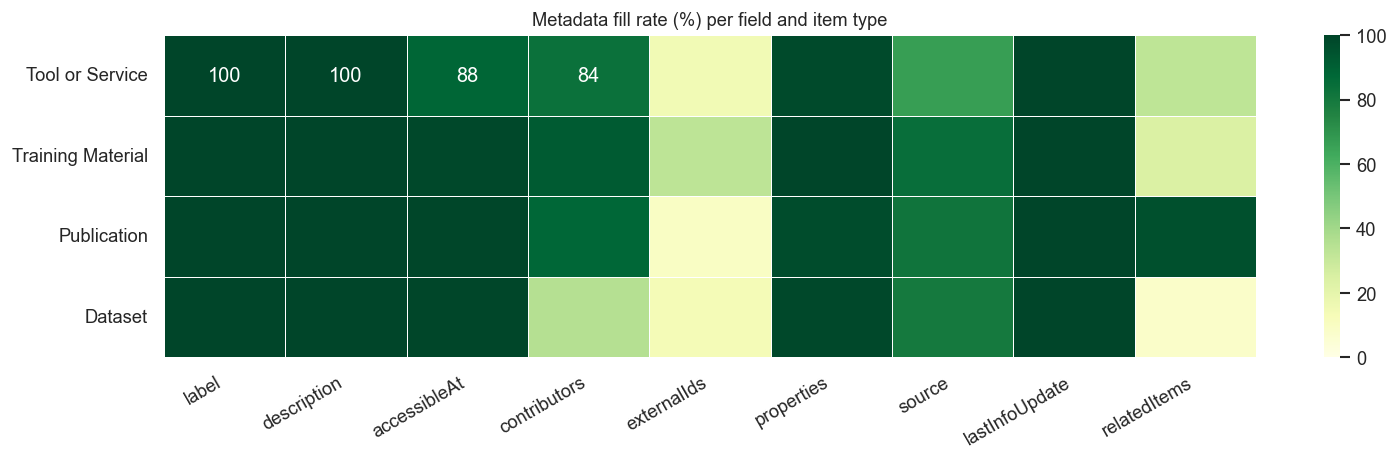

In [14]:
# These are the key fields I want to check
FIELDS_TO_CHECK = [
    "label",          # the item title
    "description",    # free text description
    "accessibleAt",   # URLs to access the resource
    "contributors",   # credited people or organisations
    "externalIds",    # persistent identifiers like DOI
    "properties",     # controlled vocabulary tags
    "source",         # which aggregator provided this item
    "lastInfoUpdate", # when was it last updated
    "relatedItems",   # links to related items
]

def is_filled(value):
    """Return True if the value actually contains something useful."""
    if value is None:
        return False
    if isinstance(value, list):
        return len(value) > 0   # a non-empty list counts as filled
    if isinstance(value, dict):
        return len(value) > 0
    return str(value).strip() != ""  # a non-empty string counts as filled

# Calculate fill rate for each field, for each item type
# fill rate = how many items have this field filled / total items
completeness = {}

for type_label, items in all_samples.items():
    if len(items) == 0:  # skip types with no data
        continue
    field_rates = {}
    for field in FIELDS_TO_CHECK:
        filled_count = sum(1 for item in items if is_filled(item.get(field)))
        field_rates[field] = filled_count / len(items)  # convert to 0-1
    completeness[type_label] = field_rates

# Turn into a dataframe: rows = item types, columns = fields
comp_df = pd.DataFrame(completeness).T

# Draw as a heatmap (multiply by 100 to show percentages)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    comp_df * 100,
    annot=True,        # show numbers inside each cell
    fmt=".0f",         # no decimal places
    cmap="YlGn",       # yellow = low, green = high
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)
ax.set_title("Metadata fill rate (%) per field and item type", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

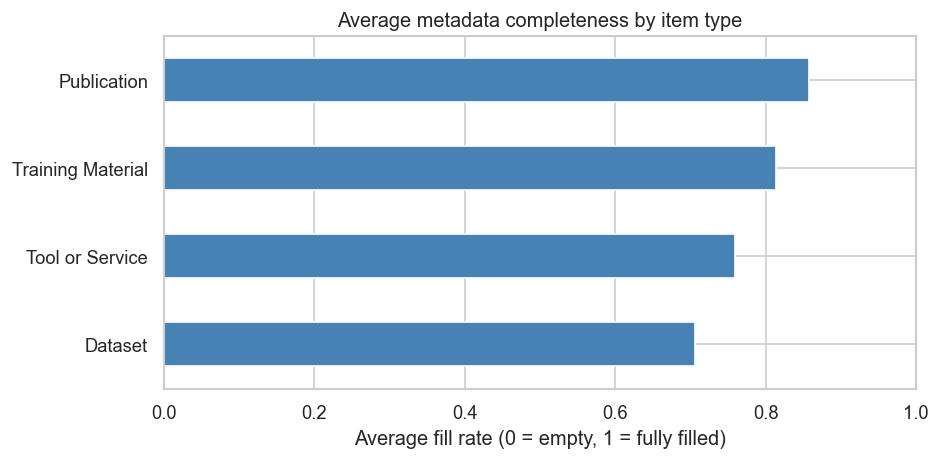

Average metadata completeness per type:
  Publication               86%
  Training Material         81%
  Tool or Service           76%
  Dataset                   71%

Finding: Some item types have significantly better metadata completeness
than others, indicating inconsistent curation standards across sources.


In [21]:
# Which item type has the best average metadata completeness overall?
# We calculate the average fill rate across all fields for each type

overall_completeness = comp_df.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
overall_completeness.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Average metadata completeness by item type")
ax.set_xlabel("Average fill rate (0 = empty, 1 = fully filled)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Average metadata completeness per type:")
for t, rate in overall_completeness.items():
    print(f"  {t:<25} {rate:.0%}")

print()
print("Finding: Some item types have significantly better metadata completeness")
print("than others, indicating inconsistent curation standards across sources.")

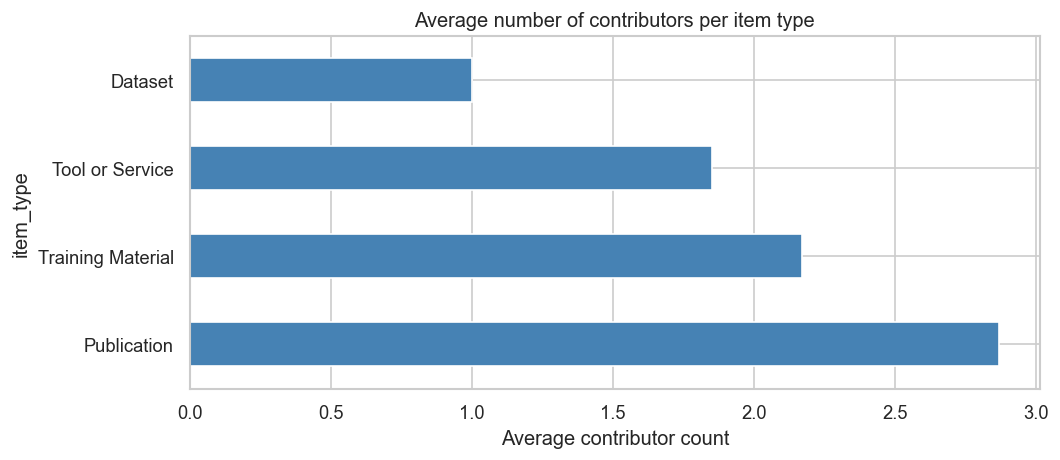

Contributor count summary across all sampled items:
count    800.00
mean       1.97
std        2.49
min        0.00
25%        0.00
50%        1.00
75%        3.00
max       28.00

Finding: Most items have very few contributors, suggesting
limited collaborative metadata curation.


In [22]:
# How many contributors does each item have?
# contributors is a list, so we count how many are in each list

contributor_counts = []
for type_label, items in all_samples.items():
    for item in items:
        count = len(item.get("contributors", []))
        contributor_counts.append({"item_type": type_label, "contributors": count})

contrib_df = pd.DataFrame(contributor_counts)

fig, ax = plt.subplots(figsize=(9, 4))
contrib_df.groupby("item_type")["contributors"].mean().sort_values().plot(
    kind="barh", ax=ax, color="steelblue"
)
ax.set_title("Average number of contributors per item type")
ax.set_xlabel("Average contributor count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Contributor count summary across all sampled items:")
print(contrib_df["contributors"].describe().round(2).to_string())
print()
print("Finding: Most items have very few contributors, suggesting")
print("limited collaborative metadata curation.")

In [15]:
# Print the fields with the lowest average fill rate
avg_fill = comp_df.mean()  # average across all item types

print("Fields with lowest average fill rate (biggest gaps):")
for field, rate in avg_fill.sort_values().head(4).items():
    print(f"  {field:<20} {rate:.0%}")

print()
print("Why this matters:")
print("'externalIds' being sparse means most items lack a DOI or persistent identifier.")
print("This makes it hard to link items to other scholarly systems like OpenAIRE.")
print("'relatedItems' being sparse means the connections between tools, workflows")
print("and training materials are underdeveloped.")

Fields with lowest average fill rate (biggest gaps):
  externalIds          18%
  relatedItems         40%
  contributors         75%
  source               78%

Why this matters:
'externalIds' being sparse means most items lack a DOI or persistent identifier.
This makes it hard to link items to other scholarly systems like OpenAIRE.
'relatedItems' being sparse means the connections between tools, workflows
and training materials are underdeveloped.


## Question 3 – Which controlled vocabularies are used, and which concepts are most common?

Each item has a `properties` list. Each property has a `type` (e.g. Activity, Keyword, Language) and a `concept` from a named vocabulary (e.g. TaDiRAH 2, ISO 639-3).

In [16]:
# Collect all concept annotations from all items into one big list
all_annotations = []

for type_label, items in all_samples.items():
    for item in items:
        for prop in item.get("properties", []):
            concept = prop.get("concept", {})
            
            # Skip non-concept properties (some are plain text values, not concepts)
            if not isinstance(concept, dict) or not concept:
                continue
            
            vocab = concept.get("vocabulary", {})
            
            all_annotations.append({
                "item_type":     type_label,
                "property_type": prop.get("type", {}).get("label", ""),
                "concept_label": concept.get("label", ""),
                "vocabulary":    vocab.get("label", "") if isinstance(vocab, dict) else "",
            })

# Turn into a dataframe
props_df = pd.DataFrame(all_annotations)

print(f"Total concept annotations found: {len(props_df):,}")
print(f"Distinct property types: {props_df['property_type'].nunique()}")
print(f"Distinct vocabularies  : {props_df['vocabulary'].nunique()}")
print()
print("Most common property types:")
print(props_df['property_type'].value_counts().head(6).to_string())

Total concept annotations found: 4,110
Distinct property types: 16
Distinct vocabularies  : 15

Most common property types:
property_type
Keyword              1355
Language              717
Activity              705
Discipline            379
License               209
Intended audience     195


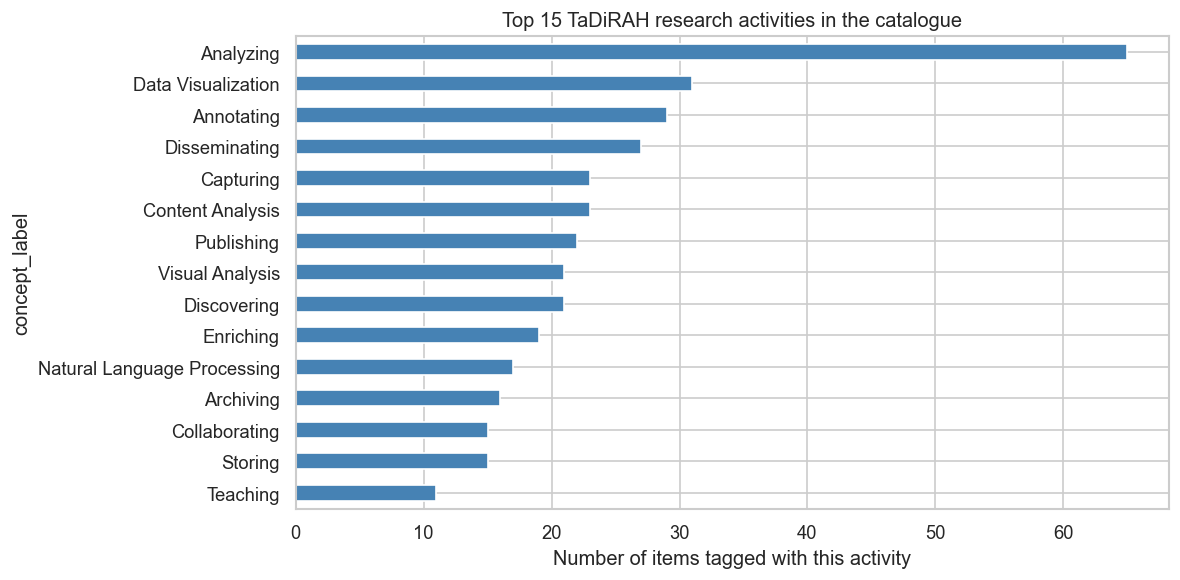

TaDiRAH is the main vocabulary for research activities in Social Sciences and Humanities.
The chart shows what researchers primarily use the Marketplace to find:
tools for Analyzing, Capturing, and Annotating data.


In [17]:
# Show the most common TaDiRAH activity concepts
# TaDiRAH = the main research activity vocabulary used in SSH
tadirah = props_df[
    props_df["vocabulary"].str.contains("TaDiRAH", case=False, na=False)
]

top_activities = tadirah["concept_label"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_activities.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 TaDiRAH research activities in the catalogue")
ax.set_xlabel("Number of items tagged with this activity")
ax.invert_yaxis()  # show most common at top
plt.tight_layout()
plt.show()

print("TaDiRAH is the main vocabulary for research activities in Social Sciences and Humanities.")
print("The chart shows what researchers primarily use the Marketplace to find:")
print("tools for Analyzing, Capturing, and Annotating data.")

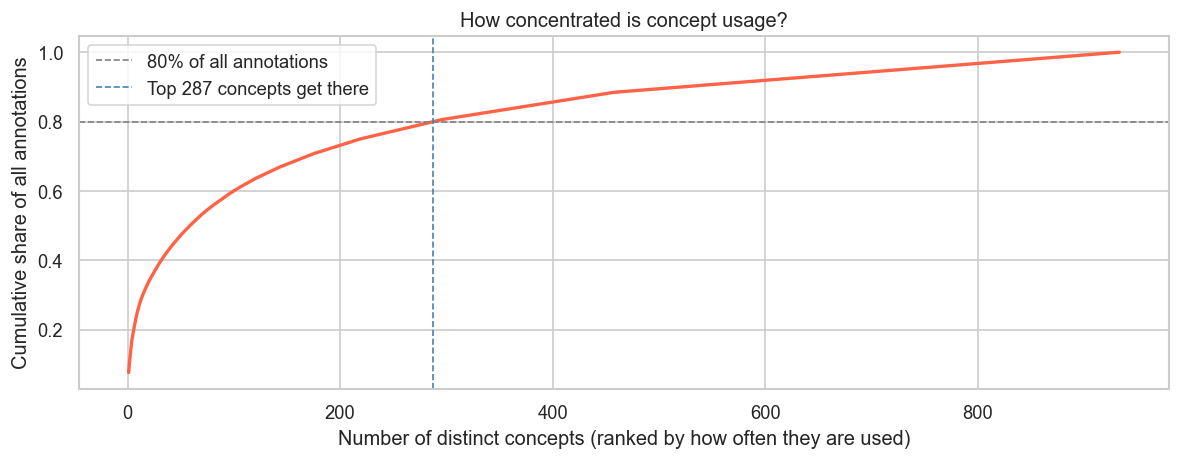

Just 287 concepts (out of 933 distinct ones) account for 80% of all annotations.
This means there is a long tail of rarely-used concepts.


In [18]:
# Vocabulary fragmentation:
# If a small number of concepts cover most of the tags, vocabulary is concentrated.
# If you need hundreds of concepts to cover 80% of tags, it is fragmented.

concept_counts = props_df["concept_label"].value_counts()
cumulative = concept_counts.cumsum() / concept_counts.sum()  # running total as fraction
n_for_80pct = (cumulative <= 0.80).sum()  # how many concepts needed to reach 80%

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumulative) + 1), cumulative.values, color="tomato", lw=2)
ax.axhline(0.80, ls="--", color="gray", lw=1, label="80% of all annotations")
ax.axvline(n_for_80pct, ls="--", color="steelblue", lw=1,
           label=f"Top {n_for_80pct} concepts get there")
ax.set_xlabel("Number of distinct concepts (ranked by how often they are used)")
ax.set_ylabel("Cumulative share of all annotations")
ax.set_title("How concentrated is concept usage?")
ax.legend()
plt.tight_layout()
plt.show()

total_concepts = concept_counts.shape[0]
print(f"Just {n_for_80pct} concepts (out of {total_concepts} distinct ones) "
      f"account for 80% of all annotations.")
print("This means there is a long tail of rarely-used concepts.")

## Question 4 – Which sources contribute the most items?

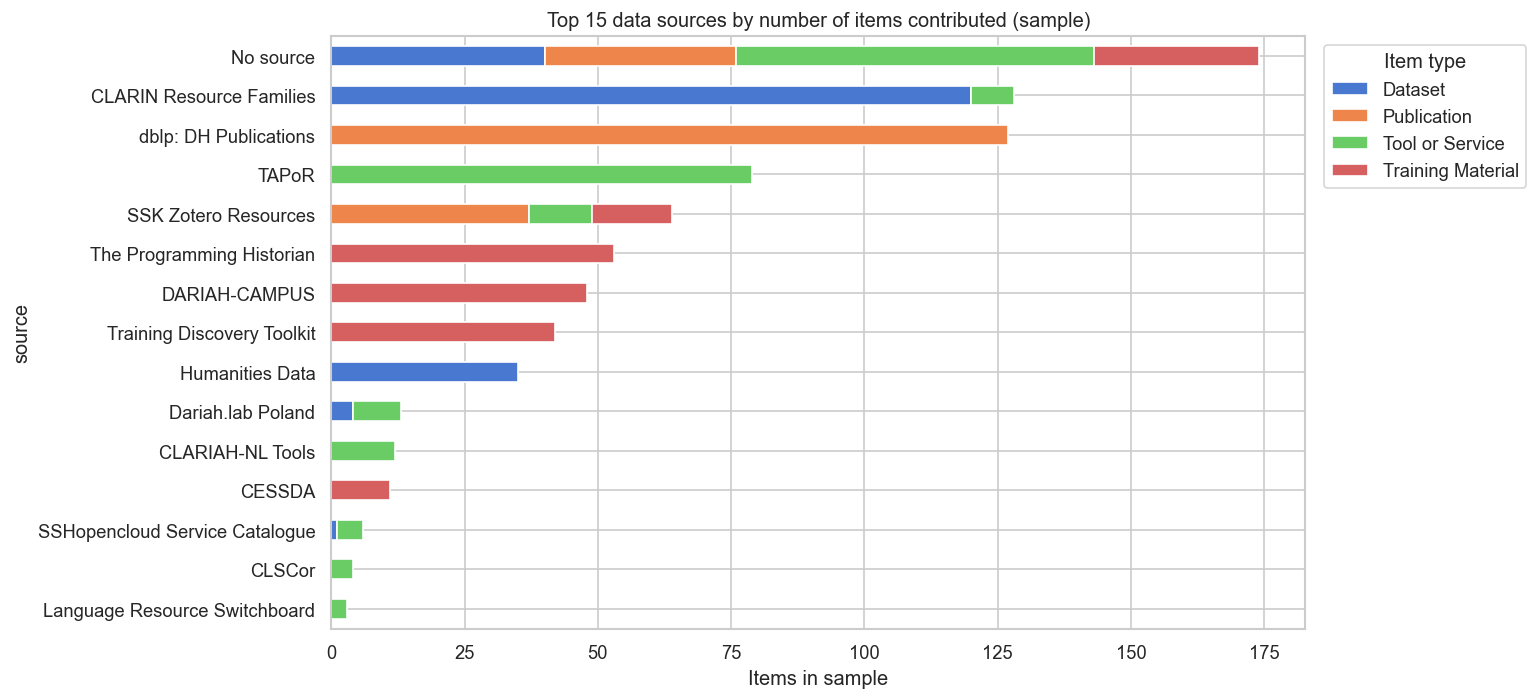

Top 5 sources:
  No source                           174 items
  CLARIN Resource Families            128 items
  dblp: DH Publications               127 items
  TAPoR                               79 items
  SSK Zotero Resources                64 items


In [19]:
# Build a flat list of (source, item_type) pairs
source_rows = []
for type_label, items in all_samples.items():
    for item in items:
        src = item.get("source") or {}  # source is a dict like {"label": "TAPoR", ...}
        src_name = src.get("label", "No source") if isinstance(src, dict) else "No source"
        source_rows.append({"source": src_name, "item_type": type_label})

source_df = pd.DataFrame(source_rows)

# Count items per source per type, then keep top 15 sources
pivot = (
    source_df
    .groupby(["source", "item_type"])
    .size()
    .unstack(fill_value=0)
)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
pivot.drop(columns="total").plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=sns.color_palette("muted", pivot.shape[1] - 1)
)
ax.set_title("Top 15 data sources by number of items contributed (sample)")
ax.set_xlabel("Items in sample")
ax.invert_yaxis()
ax.legend(title="Item type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Top 5 sources:")
for source, row in pivot.head(5).iterrows():
    print(f"  {source:<35} {int(row['total'])} items")

## Question 5 – How recently have items been updated?

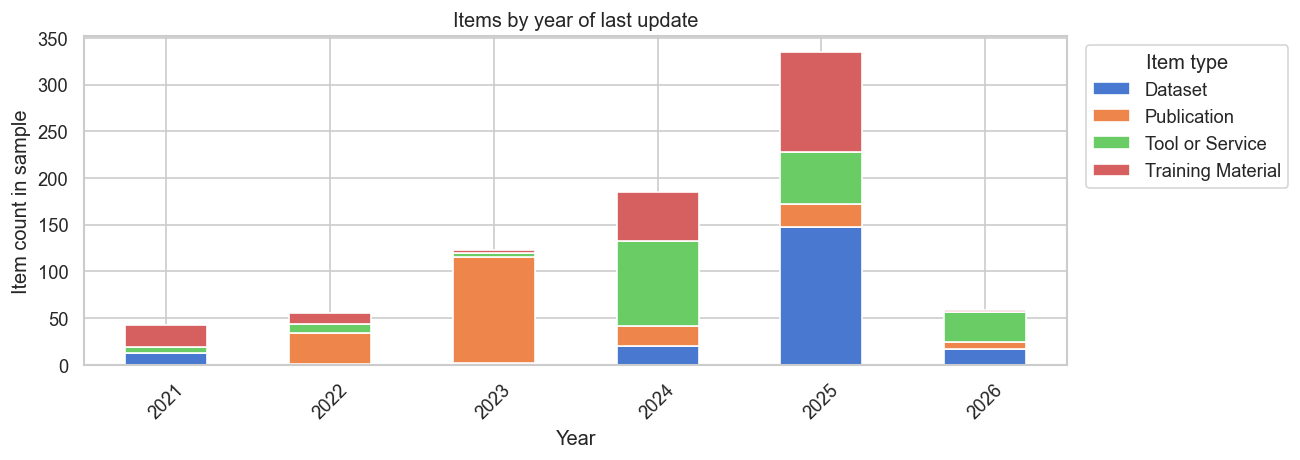

579 out of 800 sampled items (72%) were last updated in 2024 or later.

Note: lastInfoUpdate changes when an item is re-indexed, not just when its
content changes. So this is a proxy for catalogue activity, not content freshness.


In [20]:
# Extract the year from lastInfoUpdate for each item
# lastInfoUpdate looks like: '2025-01-30T09:59:57+0000'
# The first 4 characters are the year

date_rows = []
for type_label, items in all_samples.items():
    for item in items:
        date_str = item.get("lastInfoUpdate")  # e.g. '2025-01-30T09:59:57+0000'
        if date_str:
            year = int(date_str[:4])  # just take the first 4 characters
            date_rows.append({"item_type": type_label, "year": year})

date_df = pd.DataFrame(date_rows)

# Count items per year per type
year_counts = date_df.groupby(["year", "item_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
year_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=sns.color_palette("muted", year_counts.shape[1])
)
ax.set_title("Items by year of last update")
ax.set_xlabel("Year")
ax.set_ylabel("Item count in sample")
ax.legend(title="Item type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# How many items were updated recently?
recent = date_df[date_df["year"] >= 2024].shape[0]
total  = date_df.shape[0]
print(f"{recent} out of {total} sampled items ({recent/total:.0%}) were last updated in 2024 or later.")
print()
print("Note: lastInfoUpdate changes when an item is re-indexed, not just when its")
print("content changes. So this is a proxy for catalogue activity, not content freshness.")

## Summary of Findings

| Question | Finding |
|----------|---------|
| Type distribution | Training Materials and Publications dominate; Workflows are rare |
| Metadata completeness | `label`, `description`, `source` are well filled; `externalIds` and `relatedItems` are sparse |
| Controlled vocabularies | TaDiRAH 2 is the main activity vocabulary; Analyzing and Capturing are the most common activities |
| Source coverage | A small number of aggregators (TAPoR, Dariah.lab) contribute the majority of tools |
| Recency | Most items show recent update timestamps, suggesting active catalogue maintenance |

## Reflection – What I Would Do Differently With More Time

**More data:** I fetched 200 items per type as a sample. With more time I would fetch the full catalogue (2,691 tools alone) to get more reliable statistics, especially for completeness rates.

**Deeper vocabulary analysis:** I would map TaDiRAH concepts to their parent categories (Capture, Analysis, Dissemination etc.) to see which research phases are well-covered and which are missing.

**Source quality comparison:** Cross-tabulate metadata completeness by source — which aggregators produce the richest records? This would help DARIAH prioritise which data pipelines to improve.

**Time series:** Parse the full date (not just year) to see monthly ingestion trends — are there spikes after specific funding calls or events?

**Caching:** Save raw API responses to disk so the notebook can be re-run without hitting the API again, which is faster and politer to the server.